In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import joblib

In [3]:
df = pd.read_csv("ecommerce_cleaned.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 30)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status,Order_DayOfWeek,Is_Loss,Revenue_Per_Unit,Discount_Category
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,32.91,2.25,Economy,4,Google Pay,Delivered,2,0,520.400000,No Discount
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,16.41,4.72,Economy,5,Credit Card,Delivered,0,0,16.940000,High (21-30%)
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,33.11,13.28,Standard,8,Credit Card,Processing,3,0,241.300000,No Discount
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,43.60,31.11,Express,16,Google Pay,Processing,4,0,130.900000,No Discount
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,33.63,8.44,Standard,5,Debit Card,Delivered,6,0,59.606667,Medium (11-20%)


In [4]:
DROP_COLS = ['Is_Loss', 'Order_ID', 'Customer_ID', 'Order_Date',
             'Product_Name', 'Order_DayOfWeek', 'Discount_Category']

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
X = X.select_dtypes(include=[np.number])
y = df['Is_Loss']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 12)
y shape: (10000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

Training set : 8000 samples
Test set     : 2000 samples


In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")

Random Forest trained successfully!
Number of trees: 100


In [7]:
rf_pred = rf_model.predict(X_test)
print("Predictions generated on test set.")
print(f"First 10 predicted: {rf_pred[:10]}")
print(f"First 10 actual   : {y_test.values[:10]}")

Predictions generated on test set.
First 10 predicted: [0 0 0 0 0 0 0 0 0 0]
First 10 actual   : [0 0 0 0 0 0 0 0 0 0]


In [8]:
rf_accuracy  = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall    = recall_score(y_test, rf_pred)
rf_f1        = f1_score(y_test, rf_pred)

print("=" * 50)
print("RANDOM FOREST — PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy  : {rf_accuracy*100:.2f}%")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")
print()
print("F1 Formula: 2 x (Precision x Recall) / (Precision + Recall)")
manual_f1 = 2 * (rf_precision * rf_recall) / (rf_precision + rf_recall)
print(f"Manual F1 verification: {manual_f1:.4f}")

RANDOM FOREST — PERFORMANCE METRICS
Accuracy  : 100.00%
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

F1 Formula: 2 x (Precision x Recall) / (Precision + Recall)
Manual F1 verification: 1.0000


In [9]:
print("CLASSIFICATION REPORT — Random Forest")
print("=" * 50)
print(classification_report(y_test, rf_pred, target_names=['Profitable', 'Loss']))

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

  Profitable       1.00      1.00      1.00      1732
        Loss       1.00      1.00      1.00       268

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [10]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, C=1.0))
])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_accuracy  = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall    = recall_score(y_test, lr_pred)
lr_f1        = f1_score(y_test, lr_pred)

print("LOGISTIC REGRESSION — PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy  : {lr_accuracy*100:.2f}%")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1-Score  : {lr_f1:.4f}")

LOGISTIC REGRESSION — PERFORMANCE METRICS
Accuracy  : 99.65%
Precision : 0.9851
Recall    : 0.9888
F1-Score  : 0.9870


In [11]:
print("=" * 60)
print(f"{'Metric':<20} {'Logistic Regression':>20} {'Random Forest':>15}")
print("-" * 60)
print(f"{'Accuracy':<20} {lr_accuracy*100:>19.2f}% {rf_accuracy*100:>14.2f}%")
print(f"{'Precision':<20} {lr_precision:>20.4f} {rf_precision:>15.4f}")
print(f"{'Recall':<20} {lr_recall:>20.4f} {rf_recall:>15.4f}")
print(f"{'F1-Score':<20} {lr_f1:>20.4f} {rf_f1:>15.4f}")
print("=" * 60)
winner = "Random Forest" if rf_f1 >= lr_f1 else "Logistic Regression"
print(f"Best Model (by F1): {winner}")

Metric                Logistic Regression   Random Forest
------------------------------------------------------------
Accuracy                           99.65%         100.00%
Precision                          0.9851          1.0000
Recall                             0.9888          1.0000
F1-Score                           0.9870          1.0000
Best Model (by F1): Random Forest


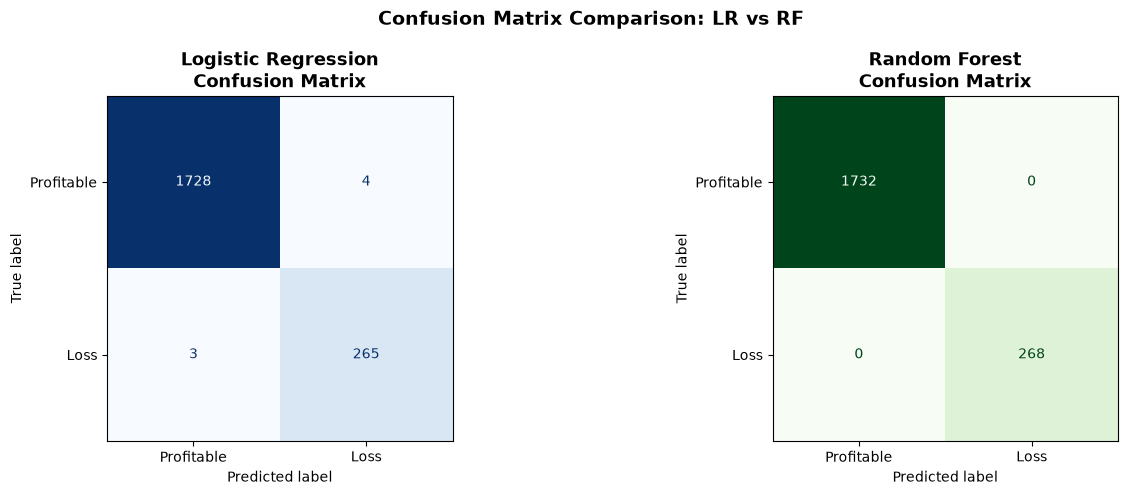

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_lr = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm_lr, display_labels=['Profitable','Loss']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=13, fontweight='bold')

cm_rf = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['Profitable','Loss']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison: LR vs RF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

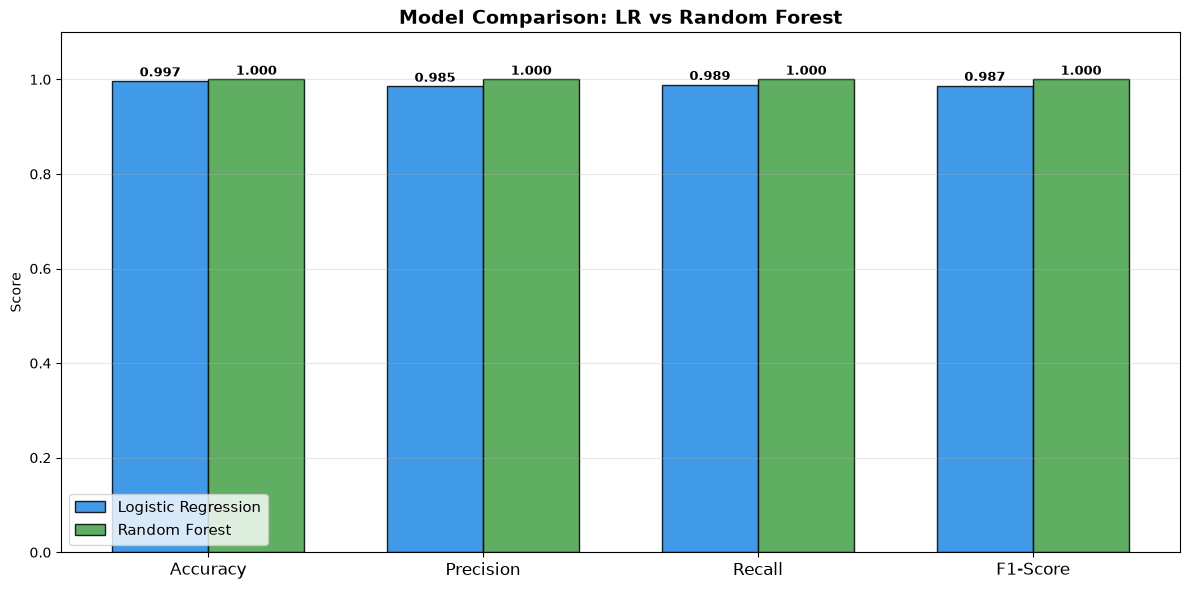

In [13]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#1E88E5', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest',
               color='#43A047', edgecolor='black', alpha=0.85)

ax.set_title('Model Comparison: LR vs Random Forest', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

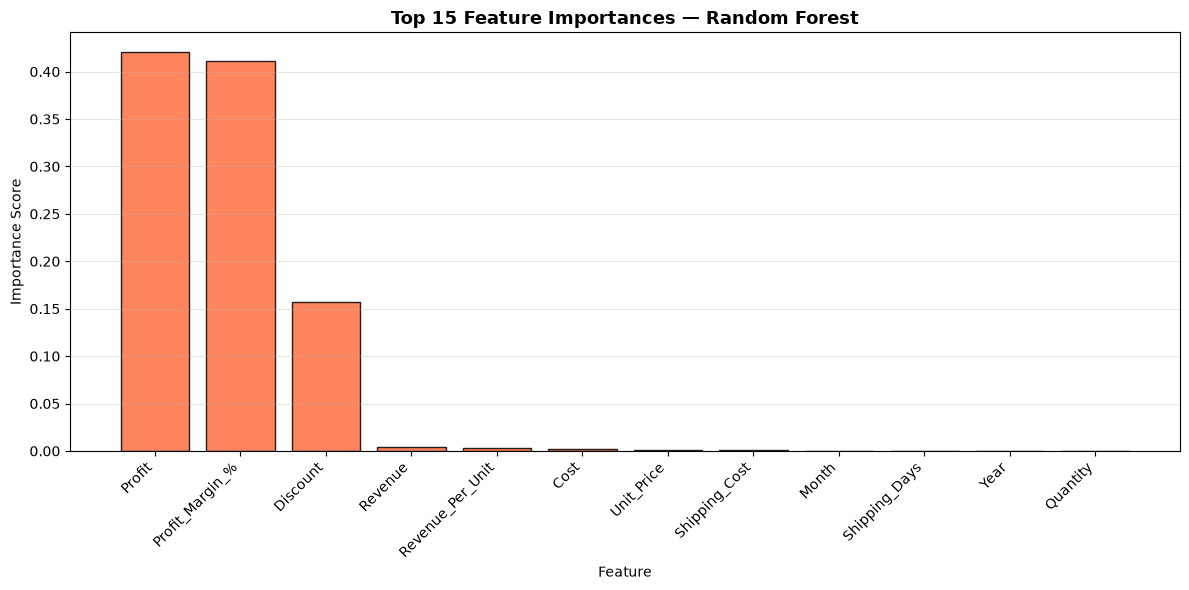

In [14]:
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.bar(feat_imp['Feature'], feat_imp['Importance'],
        color='#FF7043', edgecolor='black', alpha=0.85)
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
joblib.dump(rf_model, 'random_forest_model.pkl')
import os
size = os.path.getsize('random_forest_model.pkl') / 1024
print(f"Model saved: random_forest_model.pkl ({size:.1f} KB)")

loaded = joblib.load('random_forest_model.pkl')
verify_pred = loaded.predict(X_test)
print(f"Verification: loaded model F1 = {f1_score(y_test, verify_pred):.4f}")

Model saved: random_forest_model.pkl (151.2 KB)
Verification: loaded model F1 = 1.0000


In [16]:
print("=" * 55)
print("CONCLUSIONS")
print("=" * 55)
print(f"1. Random Forest F1    : {rf_f1:.4f}")
print(f"   Logistic Reg F1     : {lr_f1:.4f}")
print()
print("2. Why F1 > Accuracy?")
print("   Dataset has class imbalance (15% loss orders).")
print("   Accuracy alone is misleading — F1 balances")
print("   Precision and Recall for a fair evaluation.")
print()
print("3. Random Forest advantages:")
print("   - Handles non-linear relationships in data")
print("   - Robust to outliers via bagging (100 trees)")
print("   - Built-in feature importance ranking")
print("   - Less prone to overfitting vs single decision tree")
print()
print("4. Model saved as: random_forest_model.pkl")

CONCLUSIONS
1. Random Forest F1    : 1.0000
   Logistic Reg F1     : 0.9870

2. Why F1 > Accuracy?
   Dataset has class imbalance (15% loss orders).
   Accuracy alone is misleading — F1 balances
   Precision and Recall for a fair evaluation.

3. Random Forest advantages:
   - Handles non-linear relationships in data
   - Robust to outliers via bagging (100 trees)
   - Built-in feature importance ranking
   - Less prone to overfitting vs single decision tree

4. Model saved as: random_forest_model.pkl
